# Análisis estadístico

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df_final = pd.read_csv('files/df_final_limpio.csv', index_col = 0)
df_final.info()

<class 'pandas.DataFrame'>
Index: 405624 entries, 100018 to 999986
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   year                         405624 non-null  int64  
 1   date                         405624 non-null  str    
 2   flights_booked               405624 non-null  int64  
 3   flights_with_companions      405624 non-null  int64  
 4   total_flights                405624 non-null  int64  
 5   distance                     405624 non-null  int64  
 6   points_accumulated           405624 non-null  float64
 7   points_redeemed              405624 non-null  int64  
 8   dollar_cost_points_redeemed  405624 non-null  int64  
 9   country                      405624 non-null  str    
 10  province                     405624 non-null  str    
 11  city                         405624 non-null  str    
 12  postal_code                  405624 non-null  str    
 13  gender    

## Variables numéricas

In [4]:
df_final.describe().T

,count,mean,std,min,25%,50%,75%,max
year,405624.0,2017.500000,0.500001,2017.00,2017.00,2017.500000,2018.00,2018.00
flights_booked,405624.0,4.115052,5.225518,0.00,0.00,1.000000,8.00,21.00
flights_with_companions,405624.0,1.031805,2.076869,0.00,0.00,0.000000,1.00,11.00
total_flights,405624.0,5.146858,6.521227,0.00,0.00,1.000000,10.00,32.00
distance,405624.0,1208.880059,1433.155320,0.00,0.00,488.000000,2336.00,6293.00
points_accumulated,405624.0,123.692721,146.599831,0.00,0.00,50.000000,239.00,676.50
points_redeemed,405624.0,30.696872,125.486049,0.00,0.00,0.000000,0.00,876.00
dollar_cost_points_redeemed,405624.0,2.484503,10.150038,0.00,0.00,0.000000,0.00,71.00
salary,405624.0,79445.562879,29976.729425,15609.00,63991.00,79429.572642,82940.00,407228.00
clv,405624.0,7991.976226,6863.663857,1898.01,3985.32,5776.340000,8936.82,83325.38


In [5]:
# Función para sacar el análisis estadístico de cada variable por separado

def resumen_variable(df, columna):

    serie_original = df[columna]
    serie = serie_original.dropna()

    media = serie.mean()
    mediana = serie.median()
    moda = serie.mode()
    desviacion = serie.std()
    minimo = serie.min()
    maximo = serie.max()
    varianza = serie.var()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    rango_intercuartilico = q3 - q1
    rango = maximo - minimo

    if media != 0:
        coef_variacion = (desviacion / media)*100
    else:
        coef_variacion = np.nan

    resumen = pd.DataFrame({
        "variable": [columna],
        "media": [round(media, 2)],
        "mediana": [round(mediana, 2)],
        "moda": [moda.iloc[0] if len(moda) > 0 else np.nan],
        "desviacion_estandar": [round(desviacion, 2)],
        "minimo": [round(minimo, 2)],
        "maximo": [round(maximo, 2)],
        "varianza": [round(varianza, 2)],
        "q1": [round(q1, 2)],
        "q3": [round(q3, 2)],
        "rango_intercuartilico": [round(rango_intercuartilico, 2)],
        "rango": [round(rango, 2)],
        "coeficiente_variacion": [round(coef_variacion, 2)]
    }).T

    return resumen

In [6]:
resumen_variable(df_final, 'flights_booked')

,0
variable,flights_booked
media,4.12
mediana,1.0
moda,0
desviacion_estandar,5.23
minimo,0
maximo,21
varianza,27.31
q1,0.0
q3,8.0


Análisis:
- La diferencia entre la media y la mediana sugiere una distribución asimétrica hacia la derecha. Esto indica que la mayoría de registros mensuales concentra pocos vuelos reservados, mientras que una minoría presenta valores más altos que elevan la media
- Esta interpretación se refuerza con la moda, ya que el valor más frecuente es 0. Es decir, lo más habitual es que en un mes determinado no haya vuelos reservados por parte del cliente.
- La desviación estándar, la varianza y el coeficiente de variación muestran una dispersión elevada, coherente con una variable en la que conviven muchos registros sin actividad y otros con un volumen de reservas notablemente superior.
- Además, el 50% central de los datos se sitúa entre 0 y 8 vuelos reservados, lo que confirma que la mayor parte de los registros se concentra en valores relativamente bajos.

In [7]:
resumen_variable(df_final, 'flights_with_companions')

,0
variable,flights_with_companions
media,1.03
mediana,0.0
moda,0
desviacion_estandar,2.08
minimo,0
maximo,11
varianza,4.31
q1,0.0
q3,1.0


Análisis:
- En este caso, apenas hay distancia entre la media y la mediana. Y la mediana es igual que la moda.
- Una mediana igual a 0 indica que al menos la mitad de los registros presentan 0 vuelos con acompañantes.
- El máximo de vuelos con acompañante ha sido 11, aunque el boxplot muestra que estos casos son minoritarios y atípicos frente al comportamiento general de la variable

In [8]:
resumen_variable(df_final, 'total_flights')

,0
variable,total_flights
media,5.15
mediana,1.0
moda,0
desviacion_estandar,6.52
minimo,0
maximo,32
varianza,42.53
q1,0.0
q3,10.0


Análisis:

- Al igual que en las anteriores, vemos una media y una mediana alejadas, siendo la media superior a la mediana, lo que indica que algunos registros con un número alto de vuelos desplaza la media hacia arriba. 
- El coeficiente de variación es muy alto, lo que indica que hay una alta dispersión de los datos que refleja diferencias importantes en la actividad mensual de los clientes.

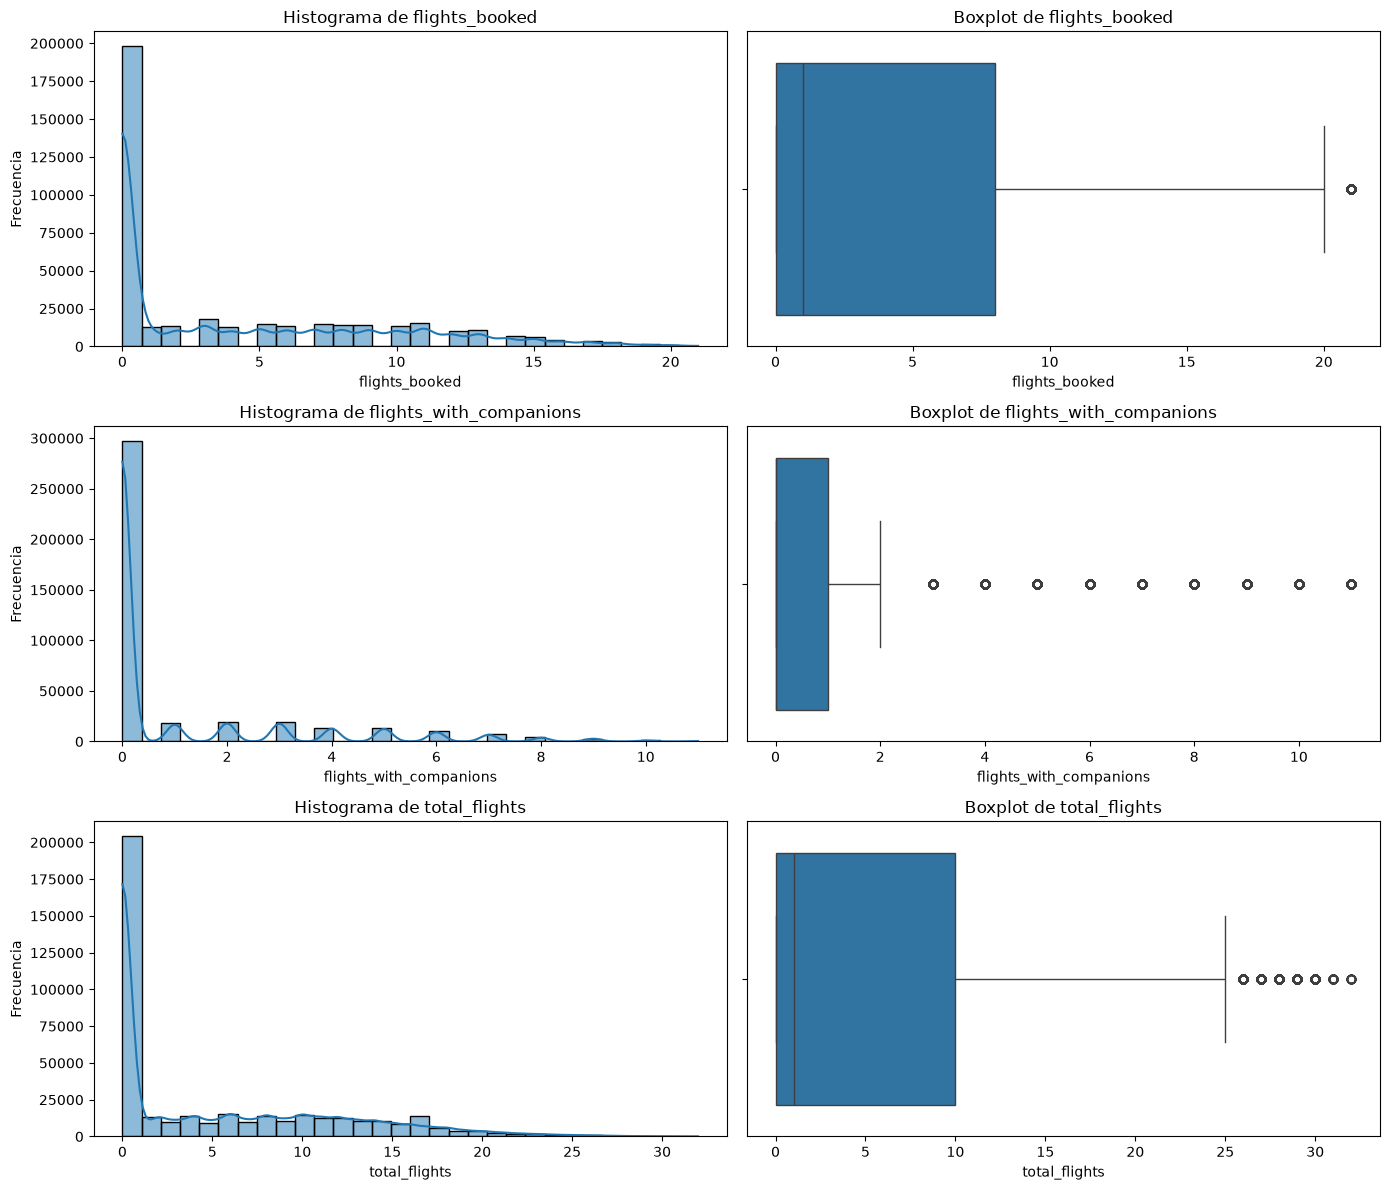

In [9]:
#Visualización de las tres variables

variables_vuelos = [
    "flights_booked",
    "flights_with_companions",
    "total_flights"
]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))

for i, variable in enumerate(variables_vuelos):
    
    # Histograma
    sns.histplot(
        data=df_final,
        x=variable,
        bins=30,
        kde=True,
        ax=axes[i, 0]
    )
    
    axes[i, 0].set_title(f"Histograma de {variable}")
    axes[i, 0].set_xlabel(variable)
    axes[i, 0].set_ylabel("Frecuencia")
    
    
    # Boxplot
    sns.boxplot(
        data=df_final,
        x=variable,
        ax=axes[i, 1]
    )
    
    axes[i, 1].set_title(f"Boxplot de {variable}")
    axes[i, 1].set_xlabel(variable)

plt.tight_layout()
plt.show()

In [10]:
resumen_variable(df_final, 'distance')

,0
variable,distance
media,1208.88
mediana,488.0
moda,0
desviacion_estandar,1433.16
minimo,0
maximo,6293
varianza,2053934.17
q1,0.0
q3,2336.0


Análisis:
- La media es bastante superior a la mediana, lo que indica una distribución asimétrica hacia la derecha
- Como en los casos anteriores el número de vuelos/mes más repetido era 0, tiene sentido que la distancia más repetida sea 0.
- Esto explica, a su vez, esta gran diferencia entre la media, la moda y la mediana, ya que las distancias en avión son muy grandes y, aunque se hagan pocos vuelos, esto ya aumentaría mucho la diferencia entre los valores.
- Por tanto, la desviación con respecto a la media es también muy alta, lo que va a derivar en una alta dispersión de los datos.

In [11]:
resumen_variable(df_final, 'points_accumulated')

,0
variable,points_accumulated
media,123.69
mediana,50.0
moda,0.0
desviacion_estandar,146.6
minimo,0.0
maximo,676.5
varianza,21491.51
q1,0.0
q3,239.0


Análisis:
- Toda la tabla está marcada por que hay muchos meses que muchos clientes no realizan vuelos.
- Partiendo de esa base, se sigue explicando que haya tanta distancia entre la media y la mediana, lo que indica que hay valores extremos. Reforzado por que la el valor más repetido en este caso también es 0
- Los datos por tanto no están concentrados ni son simétricos

In [12]:
resumen_variable(df_final, 'points_redeemed')

,0
variable,points_redeemed
media,30.7
mediana,0.0
moda,0
desviacion_estandar,125.49
minimo,0
maximo,876
varianza,15746.75
q1,0.0
q3,0.0


Análisis:
- Dado que los puntos redimidos están condicionados por los vuelos, los datos presentan un comportamiento similar, con una media y una moda igual a 0, pero con una media de 30,7, claramente distorsionada por los pocos clientes que más viajan. Lo que a su vez explica la dispersión de los datos y la asimetría de su distribución, que reflejan tanto la desviación estándar como el coeficiente de variación.

In [13]:
resumen_variable(df_final, 'dollar_cost_points_redeemed')

,0
variable,dollar_cost_points_redeemed
media,2.48
mediana,0.0
moda,0
desviacion_estandar,10.15
minimo,0
maximo,71
varianza,103.02
q1,0.0
q3,0.0


Análisis:

- En el coste en dólares de los puntos redimidos vemos también un comportamiento similar en los datos, con un coeficiente de variación muy alto que llama especialmente la atención y que demuestra una polarización extrema.


##### Cálculo estadísticas salario y clv

Para calcular las estadísticas de salario y clv, es más correcto usar una tabla que elimine los duplicados de los clientes, para que no haya distorsiones en los datos. Por ello, creamos otra tabla en la que 'loyalty_number' aparezca solo una vez.

In [14]:
df_final = df_final.reset_index()

In [15]:
df_final.head()
df_final.columns

Index(['Loyalty Number', 'year', 'date', 'flights_booked',
       'flights_with_companions', 'total_flights', 'distance',
       'points_accumulated', 'points_redeemed', 'dollar_cost_points_redeemed',
       'country', 'province', 'city', 'postal_code', 'gender', 'education',
       'salary', 'marital_status', 'loyalty_card', 'clv', 'enrollment_type',
       'enrollment_date', 'enrollment_year', 'cancellation_year',
       'cancellation_date', 'is_cancelled'],
      dtype='str')

In [16]:
df_clientes = df_final.drop_duplicates(subset="Loyalty Number")

In [17]:
df_clientes.to_csv("df_clientes.csv", index=False)

In [18]:


resumen_variable(df_clientes, 'salary')

,0
variable,salary
media,79429.57
mediana,79429.57
moda,79429.572642
desviacion_estandar,29986.17
minimo,15609.0
maximo,407228.0
varianza,899170116.48
q1,63991.0
q3,82940.0


In [19]:
def visualizar_salario(df, columna):
    
    # Eliminamos nulos solo para calcular y visualizar
    serie = df[columna].dropna()
    
    # Cálculos estadísticos
    media = serie.mean()
    mediana = serie.median()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    minimo = serie.min()
    maximo = serie.max()
    rango = maximo - minimo
    rango_intercuartilico = q3 - q1
    limite_inferior = q1 - 1.5 * rango_intercuartilico
    limite_superior = q3 + 1.5 * rango_intercuartilico

    bigote_inferior = serie[serie >= limite_inferior].min()
    bigote_superior = serie[serie <= limite_superior].max()
    
    # HISTOGRAMA
    plt.figure(figsize=(12, 6))
    
    sns.histplot(serie, kde=True, bins=30)
    
    plt.axvline(media, linestyle="--", label=f"Media: {media:.2f}", color = 'red')
    plt.axvline(mediana, linestyle="-", label=f"Mediana: {mediana:.2f}", color = '#3FE535')
    plt.axvline(q1, linestyle=":", label=f"Q1: {q1:.2f}", color = '#115749')
    plt.axvline(q3, linestyle=":", label=f"Q3: {q3:.2f}", color = '#115749')
    plt.axvline(minimo, linestyle="-.", label=f"Mínimo: {minimo:.2f}", color = '#F527DD')
    plt.axvline(maximo, linestyle="-.", label=f"Máximo: {maximo:.2f}", color = '#F527DD')
    
    plt.title("Distribución del salario")
    plt.xlabel("Salario")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.show()
    
    # BOXPLOT
    plt.figure(figsize=(12, 4))
    
    sns.boxplot(x=serie)
    
    plt.axvline(media, linestyle="--", label=f"Media: {media:.2f}", color = 'red')
    plt.axvline(mediana, linestyle="-", label=f"Mediana: {mediana:.2f}", color = '#3FE535')
    plt.axvline(q1, linestyle=":", label=f"Q1: {q1:.2f}", color = '#115749')
    plt.axvline(q3, linestyle=":", label=f"Q3: {q3:.2f}", color = '#115749')
    plt.axvline(minimo, linestyle="-.", label=f"Mínimo: {minimo:.2f}", color = '#F527DD')
    plt.axvline(maximo, linestyle="-.", label=f"Máximo: {maximo:.2f}", color = '#F527DD')

    # Bigotes reales del boxplot
    plt.axvline(bigote_inferior, linestyle="-.", label=f"Bigote inferior: {bigote_inferior:.2f}")
    plt.axvline(bigote_superior, linestyle="-.", label=f"Bigote superior: {bigote_superior:.2f}")
    
    plt.title(
        f"Boxplot del salario | Rango: {rango:.2f} | IQR: {rango_intercuartilico:.2f}"
    )
    plt.xlabel("Salario")
    plt.legend()
    plt.show()

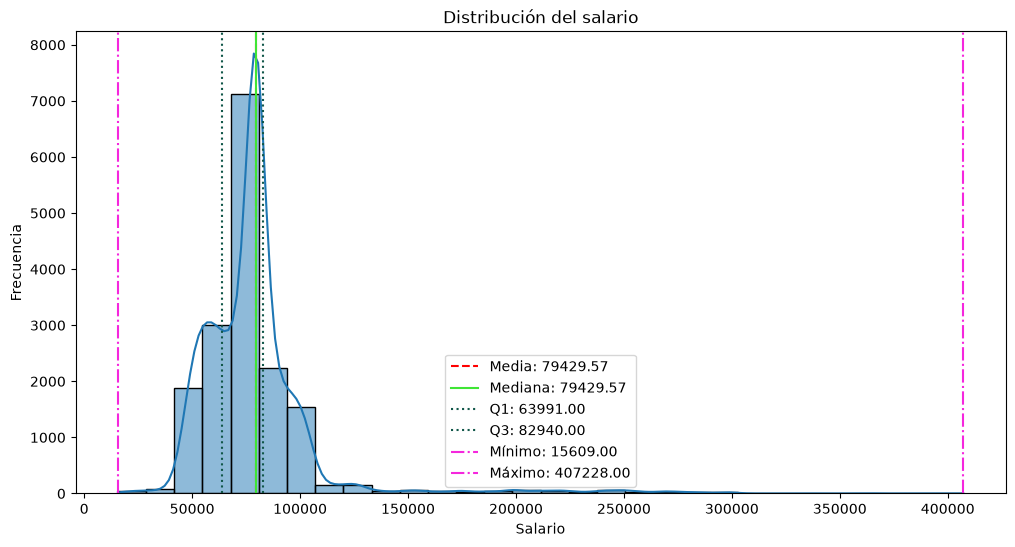

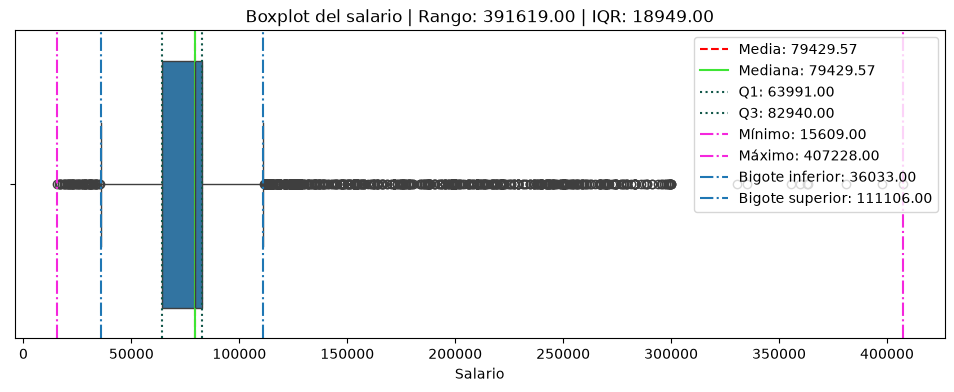

In [20]:
visualizar_salario(df_clientes, "salary")

Análisis:

- Lo que se observa es que el 50% de los salarios se encuentran entre 63.991 y 82.940
- Llama la atención la cantidad de valores atípicos hacia la derecha, con un valor máximo que alcanza los 400.000, que distorsionan los datos y generar una asimetría de su distribución hacia la derecha
- De hecho, los valores normales llegan hasta los 111.106, y más allá se consideran valores atípicos.
- En el lado izquierdo, aunque también hay valores atípicos, no son tan significativos ni numerosos.
- El salario más frecuente son 118.373
- En este caso, el coeficiente de variación también es elevado, lo que indica la presencia de valores extremos tal y como se ve en los gráficos. 

** La variable salary presenta una media y una mediana coincidentes tras la imputación, y la moda coincide con el valor central imputado. Esto indica que el método utilizado ha concentrado muchos valores ausentes en torno a un mismo salario estimado, reduciendo parcialmente la variabilidad real de la variable.

In [21]:
def visualizar_clv(df, columna):
    
    # Eliminamos nulos solo para calcular y visualizar
    serie = df[columna].dropna()
    
    # Cálculos estadísticos
    media = serie.mean()
    mediana = serie.median()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    minimo = serie.min()
    maximo = serie.max()
    rango = maximo - minimo
    rango_intercuartilico = q3 - q1
    limite_inferior = q1 - 1.5 * rango_intercuartilico
    limite_superior = q3 + 1.5 * rango_intercuartilico

    bigote_inferior = serie[serie >= limite_inferior].min()
    bigote_superior = serie[serie <= limite_superior].max()
    
    # HISTOGRAMA
    plt.figure(figsize=(12, 6))
    
    sns.histplot(serie, kde=True, bins=30)
    
    plt.axvline(media, linestyle="--", label=f"Media: {media:.2f}", color = 'red')
    plt.axvline(mediana, linestyle="-", label=f"Mediana: {mediana:.2f}", color = '#3FE535')
    plt.axvline(q1, linestyle=":", label=f"Q1: {q1:.2f}", color = '#115749')
    plt.axvline(q3, linestyle=":", label=f"Q3: {q3:.2f}", color = '#115749')
    plt.axvline(minimo, linestyle="-.", label=f"Mínimo: {minimo:.2f}", color = '#F527DD')
    plt.axvline(maximo, linestyle="-.", label=f"Máximo: {maximo:.2f}", color = '#F527DD')
    
    plt.title("Distribución del clv")
    plt.xlabel("clv")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.show()
    
    # BOXPLOT
    plt.figure(figsize=(12, 4))
    
    sns.boxplot(x=serie)
    
    plt.axvline(media, linestyle="--", label=f"Media: {media:.2f}", color = 'red')
    plt.axvline(mediana, linestyle="-", label=f"Mediana: {mediana:.2f}", color = '#3FE535')
    plt.axvline(q1, linestyle=":", label=f"Q1: {q1:.2f}", color = '#115749')
    plt.axvline(q3, linestyle=":", label=f"Q3: {q3:.2f}", color = '#115749')
    plt.axvline(minimo, linestyle="-.", label=f"Mínimo: {minimo:.2f}", color = '#F527DD')
    plt.axvline(maximo, linestyle="-.", label=f"Máximo: {maximo:.2f}", color = '#F527DD')

    # Bigotes reales del boxplot
    plt.axvline(bigote_inferior, linestyle="-.", label=f"Bigote inferior: {bigote_inferior:.2f}")
    plt.axvline(bigote_superior, linestyle="-.", label=f"Bigote superior: {bigote_superior:.2f}")
    
    plt.title(
        f"Boxplot del clv | Rango: {rango:.2f} | IQR: {rango_intercuartilico:.2f}"
    )
    plt.xlabel("clv")
    plt.legend()
    plt.show()

In [22]:
resumen_variable(df_clientes, 'clv')

,0
variable,clv
media,7988.9
mediana,5780.18
moda,8564.77
desviacion_estandar,6860.98
minimo,1898.01
maximo,83325.38
varianza,47073077.85
q1,3980.84
q3,8940.58


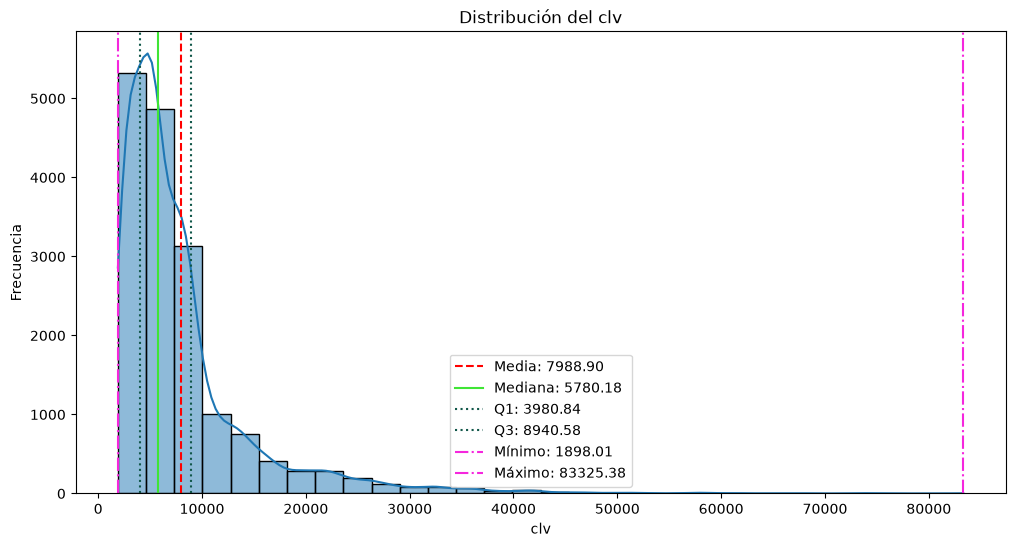

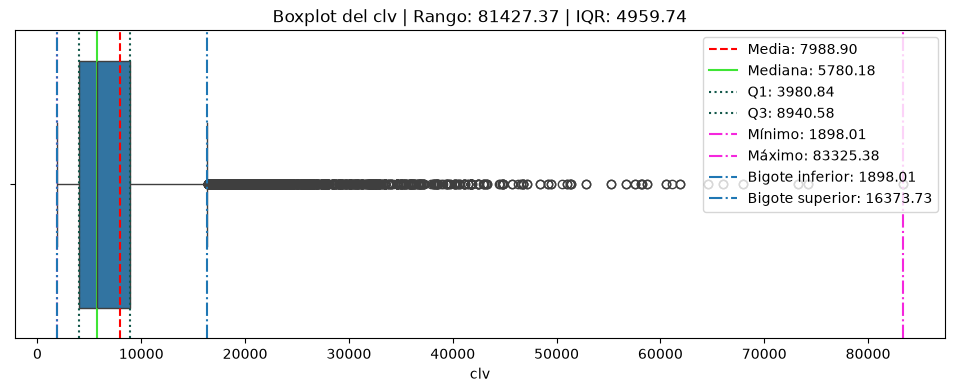

In [23]:
visualizar_clv(df_clientes, "clv")

Análisis:

La mayoría de los clientes se concentra en valores relativamente bajos de CLV, mientras que una minoría alcanza valores mucho más elevados. El rango se encuentra entre 1898 y 16373, los valores restantes hacia la derecha son outliers, que llegan hasta los 83.325, lo que da cuenta de la asimetría de los datos. Esta presencia de valores extremos desplaza la media hacia arriba, por lo que la mediana, situada en 5.780,18, resulta una medida más representativa del valor típico de los clientes.

### Correlación entre salary y clv

Correlación entre salary y clv: -0.02


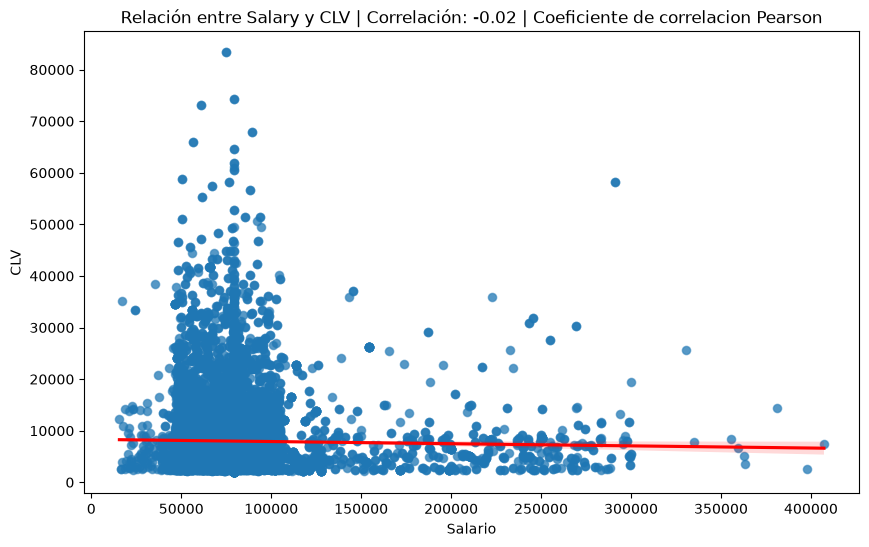

In [24]:
# Nos quedamos solo con salary y clv
df_corr = df_clientes[["salary", "clv"]]

# Calculamos correlación de Pearson
correlacion = df_corr["salary"].corr(df_corr["clv"])

print(f"Correlación entre salary y clv: {correlacion:.2f}")

# Gráfico de dispersión
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_corr,
    x="salary",
    y="clv",
    alpha=0.5
)
sns.regplot(
    data=df_corr,
    x="salary",
    y="clv",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)

plt.title(f"Relación entre Salary y CLV | Correlación: {correlacion:.2f} | Coeficiente de correlacion Pearson")
plt.xlabel("Salario")
plt.ylabel("CLV")
plt.show()

In [25]:
df_corr["salary"].corr(df_corr["clv"], method="spearman")

np.float64(-0.024141377404625283)

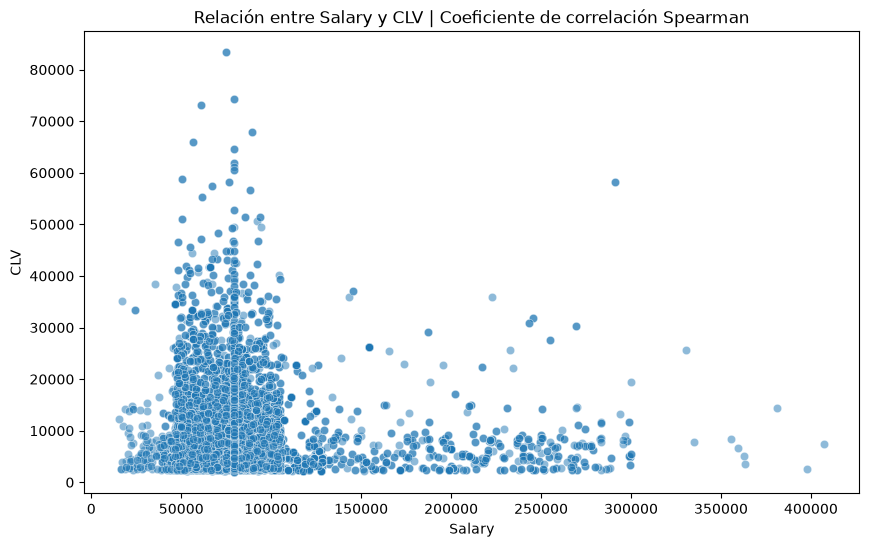

In [26]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_corr,
    x="salary",
    y="clv",
    alpha=0.5
)

plt.title("Relación entre Salary y CLV | Coeficiente de correlación Spearman")
plt.xlabel("Salary")
plt.ylabel("CLV")
plt.show()

Los gráficos de dispersión entre Salary y CLV no muestra una relación lineal clara entre ambas variables. La mayor parte de los clientes se concentra en salarios entre 50.000 y 100.000, pero dentro de ese rango se observan valores de CLV muy distintos. Además, los salarios más altos no se asocian necesariamente con un mayor CLV. Esto es coherente con una correlación de -0.03, valor muy próximo a 0, que indica ausencia de relación lineal significativa.

### Correlación entre puntos acumulados y distancia

Correlación entre distance y points_accumulated: 0.99


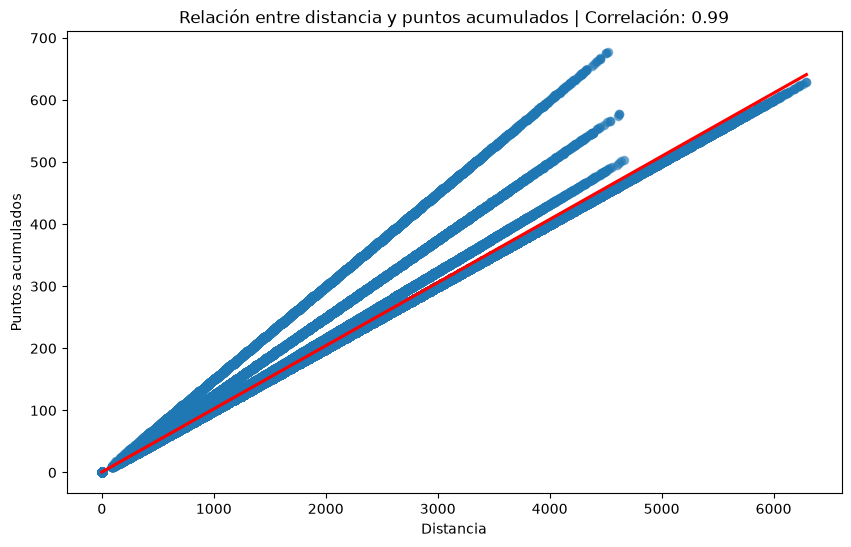

In [27]:

# Creamos un DataFrame solo con las variables que queremos comparar
df_corr_points_distance = df_final[["points_accumulated", "distance"]].dropna()

# Calculamos correlación de Pearson
correlacion = df_corr_points_distance["distance"].corr(
    df_corr_points_distance["points_accumulated"]
)

print(f"Correlación entre distance y points_accumulated: {correlacion:.2f}")

# Gráfico de dispersión
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_corr_points_distance,
    x="distance",
    y="points_accumulated",
    alpha=0.4
)
#Línea de tendencia
sns.regplot(
    data=df_corr_points_distance,
    x="distance",
    y="points_accumulated",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"}
)

plt.title(f"Relación entre distancia y puntos acumulados | Correlación: {correlacion:.2f}")
plt.xlabel("Distancia")
plt.ylabel("Puntos acumulados")
plt.show()

En este caso, se observa una correlación positiva muy fuerte entre distancia y puntos acumulados, de forma que a mayor distancia recorrida, más puntos acumulados.

## Distribución de variables categóricas

In [28]:
df_categoricas = df_clientes.select_dtypes(include="object")
df_categoricas.info()

<class 'pandas.DataFrame'>
Index: 16737 entries, 0 to 405367
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   date               16737 non-null  str  
 1   country            16737 non-null  str  
 2   province           16737 non-null  str  
 3   city               16737 non-null  str  
 4   postal_code        16737 non-null  str  
 5   gender             16737 non-null  str  
 6   education          16737 non-null  str  
 7   marital_status     16737 non-null  str  
 8   loyalty_card       16737 non-null  str  
 9   enrollment_type    16737 non-null  str  
 10  enrollment_date    16737 non-null  str  
 11  cancellation_date  2067 non-null   str  
dtypes: str(12)
memory usage: 1.7 MB


/var/folders/20/jn03hk5s5lggnql98ssngswc0000gn/T/ipykernel_55634/3688262535.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_categoricas = df_clientes.select_dtypes(include="object")


In [29]:
def resumen_categorica(df, columna):
    """
    Calcula frecuencia absoluta y porcentaje de una variable categórica.
    Devuelve un DataFrame ordenado de mayor a menor frecuencia.
    """
    
    frecuencia = df[columna].value_counts(dropna=False)
    porcentaje = df[columna].value_counts(normalize=True, dropna=False) * 100
    
    resumen = pd.DataFrame({
        "frecuencia": frecuencia,
        "porcentaje": porcentaje.round(2)
    })
    
    return resumen

In [30]:
#Analizamos las categóricas desde df cliente, porque los datos categóricos pertenecen a cada cliente
resumen_categorica(df_clientes, 'gender')

,frecuencia,porcentaje
gender,,
Female,8410,50.25
Male,8327,49.75


El número de hombres y mujeres que pertenecen al programa de lealtad de la aerolínea es muy similar, con un porcentaje ligeramente superior de mujeres.

In [31]:
resumen_categorica(df_clientes, 'education')

,frecuencia,porcentaje
education,,
Bachelor,10475,62.59
College,4238,25.32
High School or Below,782,4.67
Doctor,734,4.39
Master,508,3.04


Más de la mitad de clientes que pertenecen al programa tiene un grado universitario (Bachelor) y un cuarto tienen o Formación profesional o estudios universitarios iniciales (College). 

In [32]:
resumen_categorica(df_clientes, 'marital_status')

,frecuencia,porcentaje
marital_status,,
Married,9735,58.16
Single,4484,26.79
Divorced,2518,15.04


Casi el 60% están casados y casi el 27%, solteros. Los divorciados son minoría, con un 15%.

In [33]:
resumen_categorica(df_clientes, 'loyalty_card')

,frecuencia,porcentaje
loyalty_card,,
Star,7637,45.63
Nova,5671,33.88
Aurora,3429,20.49


Dentro de las categorías de lealtad, el 45,6% tiene la Star, el 33,8% la Nova y el 20,49% la Aurora.

In [34]:
resumen_categorica(df_clientes, 'enrollment_type')

,frecuencia,porcentaje
enrollment_type,,
Standard,15766,94.2
2018 Promotion,971,5.8


La gran mayoría tiene un tipo de inscripción Standard (94,2%), salvo un 5,8% que tiene la inscripción '2018 Promotion'

In [35]:
resumen_categorica(df_clientes, 'country')

,frecuencia,porcentaje
country,,
Canada,16737,100.0


In [36]:
resumen_categorica(df_clientes, 'province')

,frecuencia,porcentaje
province,,
Ontario,5404,32.29
British Columbia,4409,26.34
Quebec,3300,19.72
Alberta,969,5.79
Manitoba,658,3.93
New Brunswick,636,3.80
Nova Scotia,518,3.09
Saskatchewan,409,2.44
Newfoundland,258,1.54


Todos los clientes son de Canadá. Dentro del país, la mayoría proceden de Ontario (32,29), British Columbia (26,34%) y Quebec (19,72%)

In [37]:
# Visualización de las variables categóricas
variables_categoricas = df_clientes [[ 'gender','education', 'marital_status', 'loyalty_card', 'enrollment_type',
'province']]

variables_categoricas


,gender,education,marital_status,loyalty_card,enrollment_type,province
0,Female,Bachelor,Married,Aurora,Standard,Alberta
1,Male,College,Single,Nova,Standard,Ontario
2,Female,College,Divorced,Nova,Standard,British Columbia
3,Male,Bachelor,Married,Star,Standard,British Columbia
4,Female,Bachelor,Divorced,Star,Standard,Ontario
...,...,...,...,...,...,...
404026,Female,College,Married,Nova,Standard,British Columbia
404510,Male,College,Single,Nova,Standard,Ontario
404734,Female,Bachelor,Married,Star,Standard,British Columbia
405117,Male,Bachelor,Married,Nova,Standard,Ontario


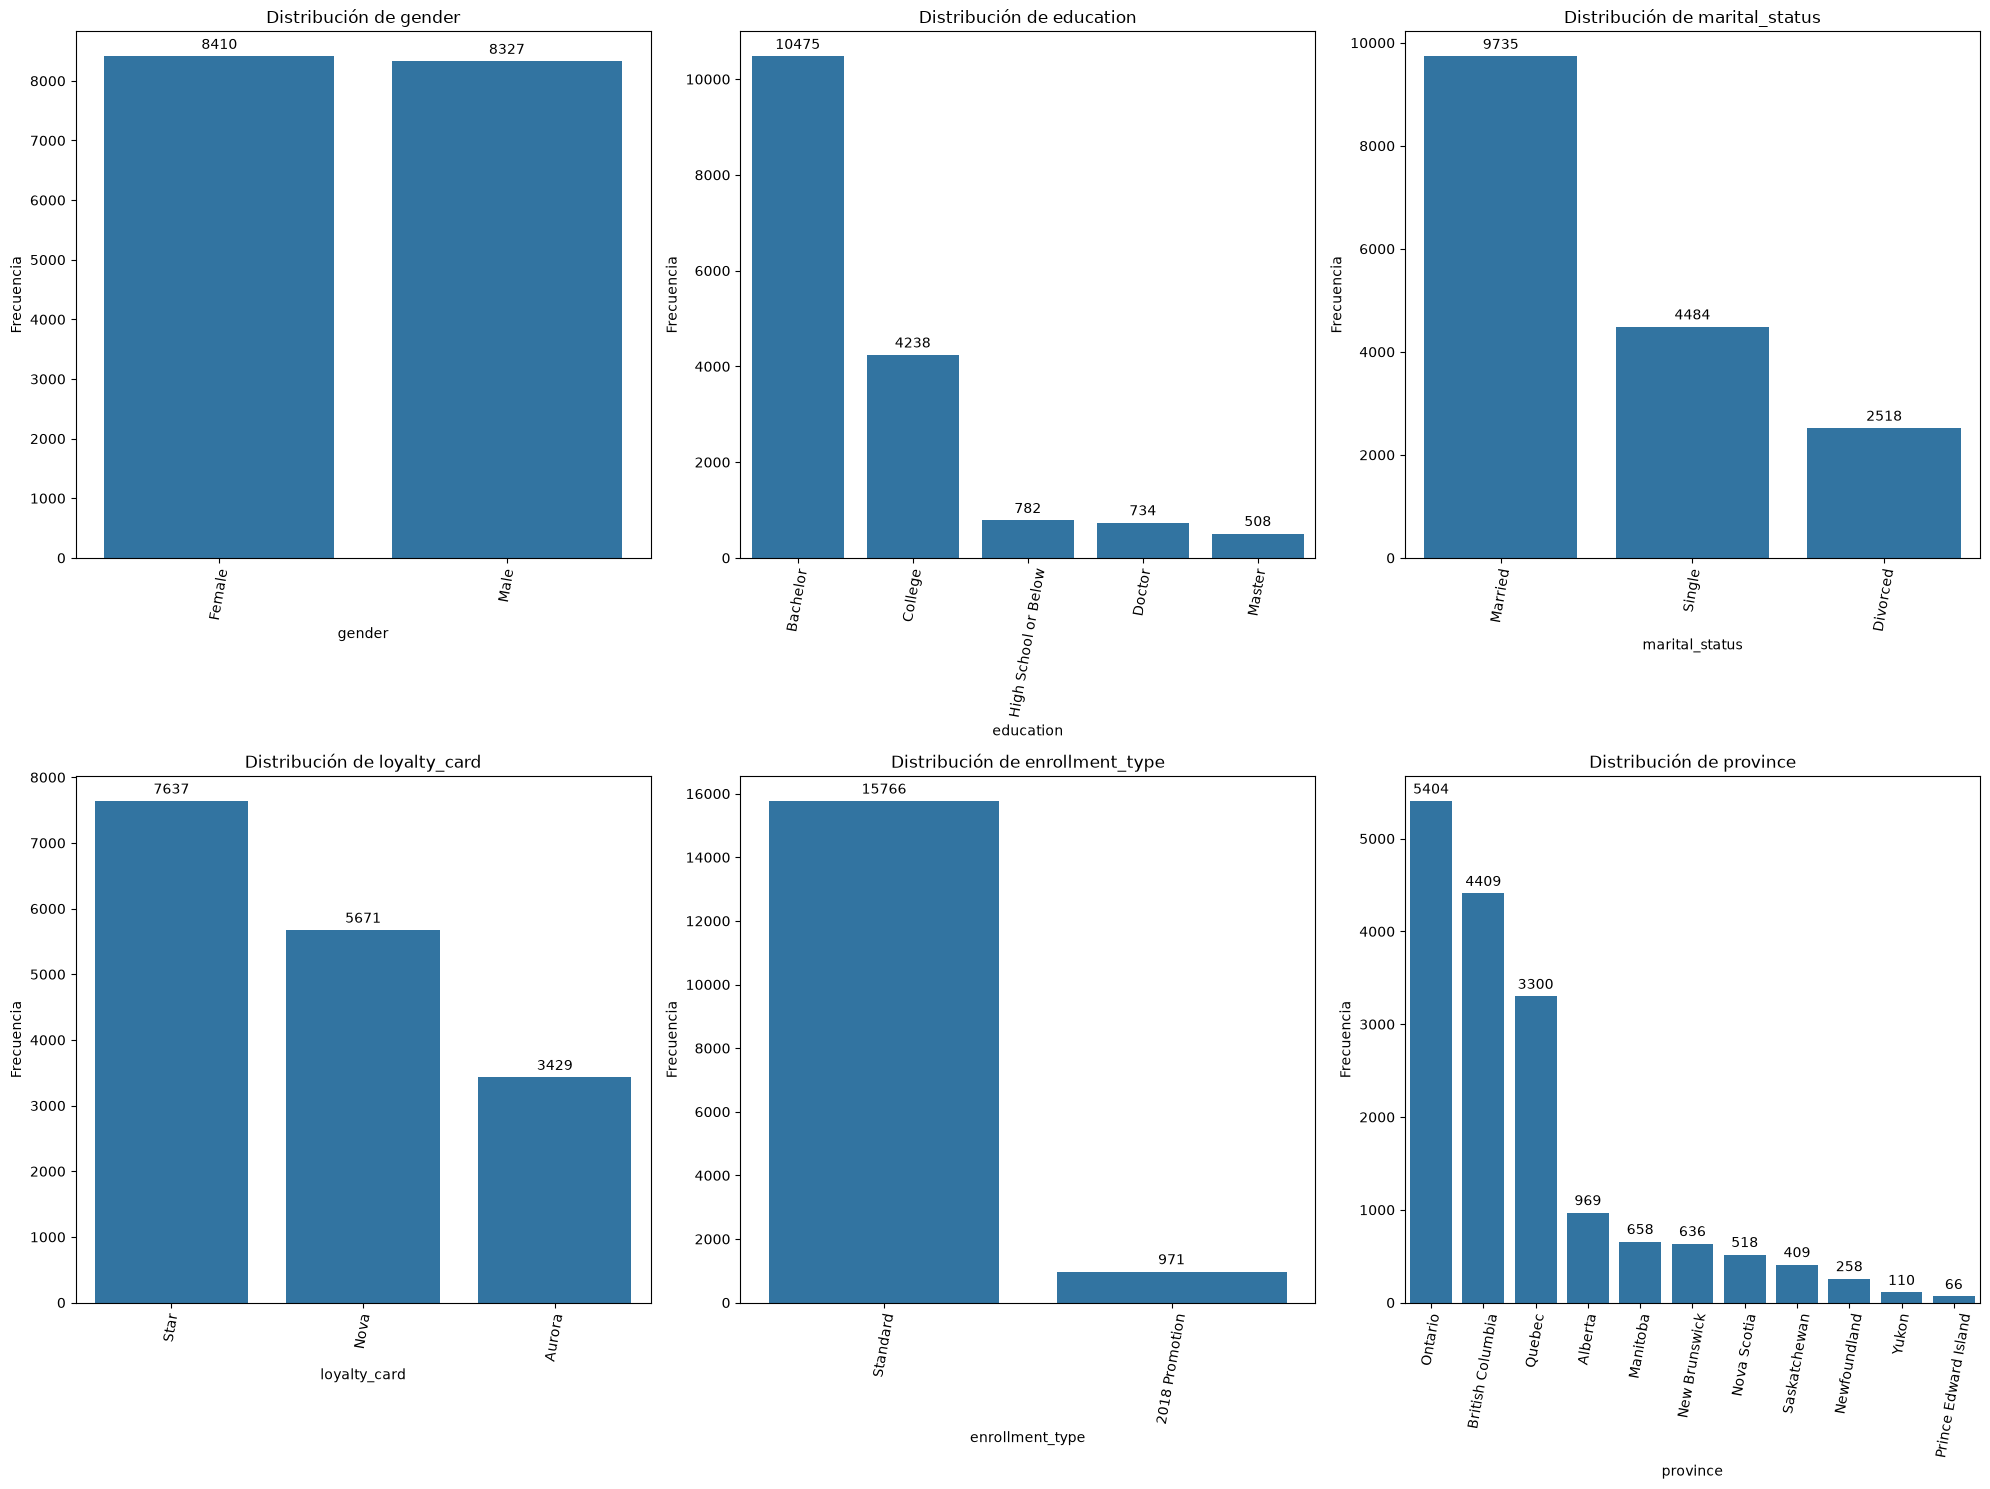

In [38]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 15))

# Aplanamos los ejes para recorrerlos más fácilmente
axes = axes.flat

for i, columna in enumerate(variables_categoricas):
    
    orden = df_clientes[columna].value_counts().index
    
    sns.countplot(
        data=df_clientes,
        x=columna,
        order=orden,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Distribución de {columna}", fontsize=12)
    axes[i].set_xlabel(columna)
    axes[i].set_ylabel("Frecuencia")
    axes[i].tick_params(axis="x", rotation=80)
    
    # Añadir etiquetas numéricas encima de cada barra
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt="%d", label_type="edge", padding=3)



plt.tight_layout()
plt.show()

# Visualización

In [39]:
# Cómo se distribuye la cantidad de vuelos reservados por mes durante el año?

## Primero paso las columna 'date' a formato datetime

df_final["date"] = pd.to_datetime(
    df_final["date"])

df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 405624 entries, 0 to 405623
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   Loyalty Number               405624 non-null  int64         
 1   year                         405624 non-null  int64         
 2   date                         405624 non-null  datetime64[us]
 3   flights_booked               405624 non-null  int64         
 4   flights_with_companions      405624 non-null  int64         
 5   total_flights                405624 non-null  int64         
 6   distance                     405624 non-null  int64         
 7   points_accumulated           405624 non-null  float64       
 8   points_redeemed              405624 non-null  int64         
 9   dollar_cost_points_redeemed  405624 non-null  int64         
 10  country                      405624 non-null  str           
 11  province                     405624 n

In [40]:
# Creo columna mes:
df_final["month"] = df_final["date"].dt.month

In [41]:
# Agrupo los vuelos por meses
vuelos_por_mes = (
    df_final.groupby("month")["flights_booked"].sum().reset_index()
)

In [42]:
vuelos_por_mes

,month,flights_booked
0,1,96936
1,2,96334
2,3,131199
3,4,112511
4,5,142170
5,6,173242
6,7,193431
7,8,169204
8,9,136379
9,10,129461


In [43]:
# Ordeno los meses para una correcta visualización
nombres_meses = {
    1: "Enero",
    2: "Febrero",
    3: "Marzo",
    4: "Abril",
    5: "Mayo",
    6: "Junio",
    7: "Julio",
    8: "Agosto",
    9: "Septiembre",
    10: "Octubre",
    11: "Noviembre",
    12: "Diciembre"
}

vuelos_por_mes["month_name"] = vuelos_por_mes["month"].map(nombres_meses)

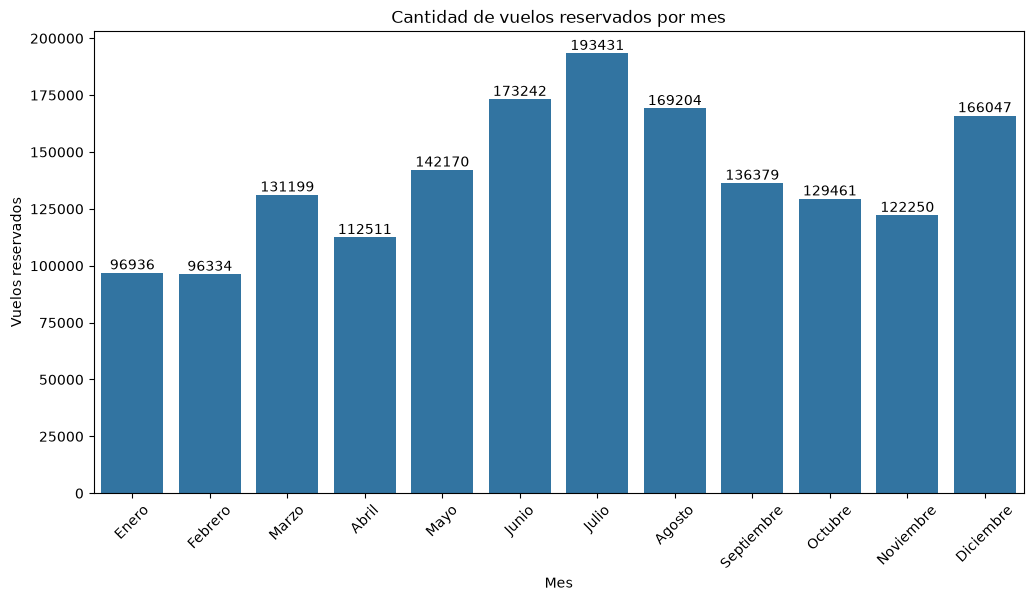

In [44]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=vuelos_por_mes,
    x="month_name",
    y="flights_booked"
)

plt.title("Cantidad de vuelos reservados por mes")
plt.xlabel("Mes")
plt.ylabel("Vuelos reservados")
plt.xticks(rotation=45)

for i, valor in enumerate(vuelos_por_mes["flights_booked"]):
    plt.text(
        i,
        valor,
        int(valor),
        ha="center",
        va="bottom"
    )

plt.show()

Con este gráfico podemos observar la demanda estacional, ya que suma los vuelos reservados por mes de los años 2017 y 2018. Como se puede ver, julio es el mes con mayor demanda, junto con junio y agosto, seguidos de diciembre. Por lo que podemos deducir que el verano, especialmente el mes de julio, y las navidades, que son los períodos vacacionales, son los meses en los que más vuelos se han reservado.

Correlación entre distance y points_accumulated: 0.99


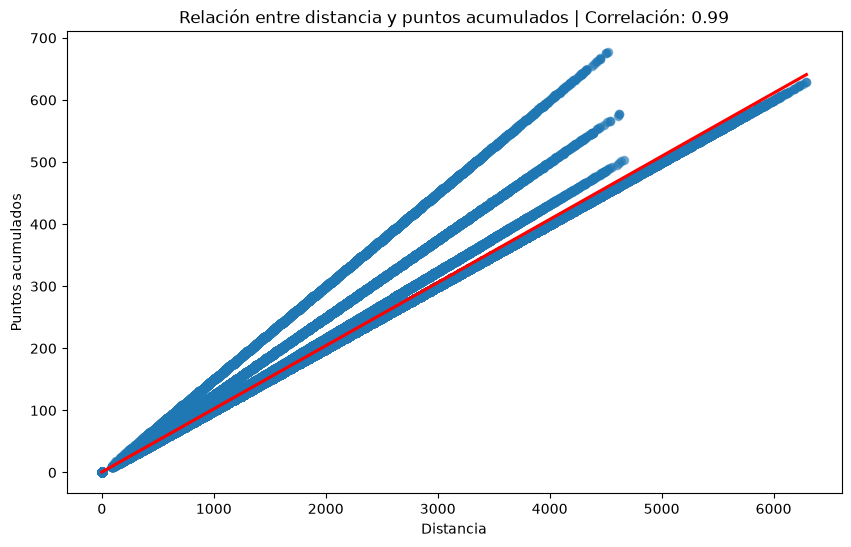

In [45]:
# Existe una relación entre la distancia de los vuelos y los puntos acumulados por los cliente?


# Creamos un DataFrame solo con las variables que queremos comparar
df_corr_points_distance = df_final[["points_accumulated", "distance"]].dropna()

# Calculamos correlación de Pearson
correlacion = df_corr_points_distance["distance"].corr(
    df_corr_points_distance["points_accumulated"]
)

print(f"Correlación entre distance y points_accumulated: {correlacion:.2f}")

# Gráfico de dispersión
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_corr_points_distance,
    x="distance",
    y="points_accumulated",
    alpha=0.4
)
#Línea de tendencia
sns.regplot(
    data=df_corr_points_distance,
    x="distance",
    y="points_accumulated",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"}
)

plt.title(f"Relación entre distancia y puntos acumulados | Correlación: {correlacion:.2f}")
plt.xlabel("Distancia")
plt.ylabel("Puntos acumulados")
plt.show()


Para ver si existe una relación entre la distancia de los vuelos y los puntos acumulados por los clientes, he realizado un gráfico de dispersión para ver si las dos variables estaban correlacionadas. Lo que se observa es que sí lo están, de hecho, tienen una correlación positiva muy fuerte, de modo que a mayor distancia más puntos acumulados.


In [46]:
df_final.columns

Index(['Loyalty Number', 'year', 'date', 'flights_booked',
       'flights_with_companions', 'total_flights', 'distance',
       'points_accumulated', 'points_redeemed', 'dollar_cost_points_redeemed',
       'country', 'province', 'city', 'postal_code', 'gender', 'education',
       'salary', 'marital_status', 'loyalty_card', 'clv', 'enrollment_type',
       'enrollment_date', 'enrollment_year', 'cancellation_year',
       'cancellation_date', 'is_cancelled', 'month'],
      dtype='str')

In [47]:
df_loyalty_number = df_final.reset_index()
df_loyalty_number = df_loyalty_number.rename(columns={'Loyalty Number': 'loyalty_number'})
df_loyalty_number

,index,loyalty_number,year,date,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,...,marital_status,loyalty_card,clv,enrollment_type,enrollment_date,enrollment_year,cancellation_year,cancellation_date,is_cancelled,month
0,0,100018,2017,2017-01-01,3,0,3,1521,152.0,0,...,Married,Aurora,7919.20,Standard,2016-08-01,2016,NaN,NaN,False,1
1,1,100102,2017,2017-01-01,10,4,14,2030,203.0,0,...,Single,Nova,2887.74,Standard,2013-03-01,2013,NaN,NaN,False,1
2,2,100140,2017,2017-01-01,6,0,6,1200,120.0,0,...,Divorced,Nova,2838.07,Standard,2016-07-01,2016,NaN,NaN,False,1
3,3,100214,2017,2017-01-01,0,0,0,0,0.0,0,...,Married,Star,4170.57,Standard,2015-08-01,2015,NaN,NaN,False,1
4,4,100272,2017,2017-01-01,0,0,0,0,0.0,0,...,Divorced,Star,6622.05,Standard,2014-01-01,2014,NaN,NaN,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405619,405619,999902,2018,2018-12-01,0,0,0,0,0.0,0,...,Married,Aurora,7290.07,Standard,2014-05-01,2014,NaN,NaN,False,12
405620,405620,999911,2018,2018-12-01,0,0,0,0,0.0,0,...,Single,Nova,8564.77,Standard,2012-08-01,2012,NaN,NaN,False,12
405621,405621,999940,2018,2018-12-01,3,0,3,1233,123.0,0,...,Married,Nova,20266.50,Standard,2017-07-01,2017,NaN,NaN,False,12
405622,405622,999982,2018,2018-12-01,0,0,0,0,0.0,0,...,Married,Star,2631.56,Standard,2018-07-01,2018,NaN,NaN,False,12


In [48]:
# Cuál es la distribución de los clientes por provincia o estado?

#Agrupo los clientes por provincia
clientes_provincia = (
    df_loyalty_number.groupby("province")["loyalty_number"].count().reset_index()
)

#Renombro la columna
clientes_provincia = clientes_provincia.rename(columns={
    "loyalty_number": "numero_clientes"
})

#Ordeno
clientes_provincia = clientes_provincia.sort_values(
    by="numero_clientes",
    ascending=False
)

In [49]:
clientes_provincia["porcentaje"] = (
    clientes_provincia["numero_clientes"] / clientes_provincia["numero_clientes"].sum() * 100
).round(2)

In [50]:
clientes_provincia.head()

,province,numero_clientes,porcentaje
6,Ontario,130896,32.27
1,British Columbia,106848,26.34
8,Quebec,79968,19.71
0,Alberta,23400,5.77
2,Manitoba,15984,3.94


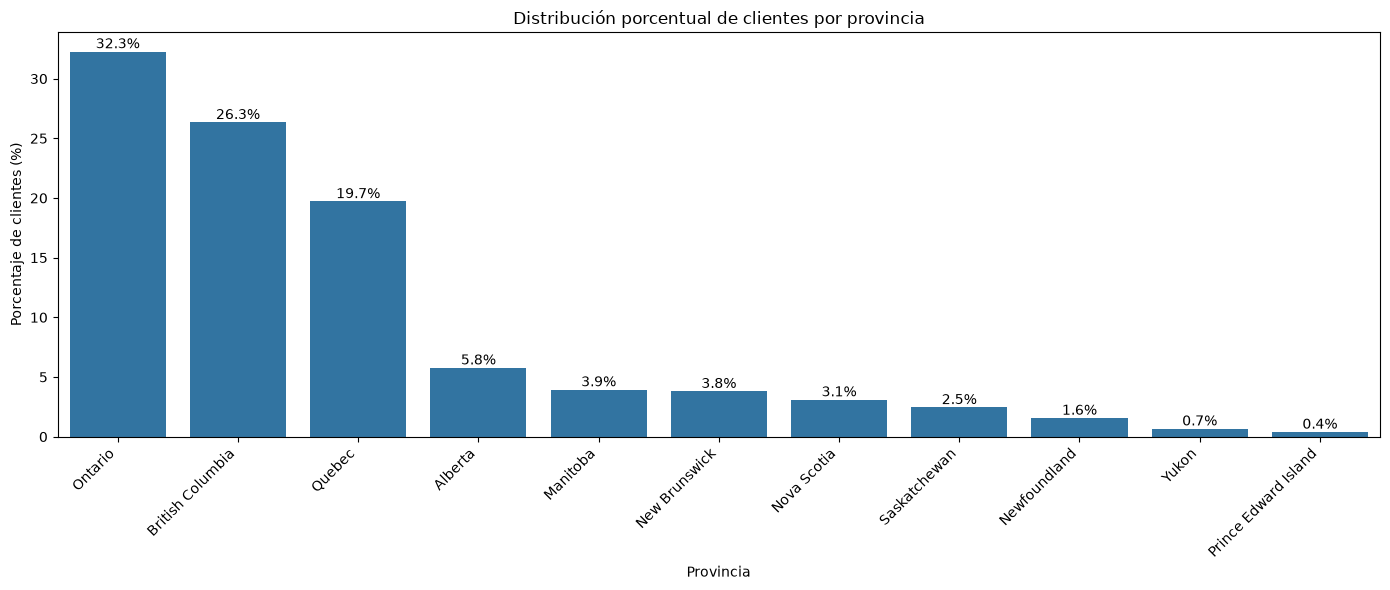

In [51]:
plt.figure(figsize=(14, 6))

sns.barplot(
    data=clientes_provincia,
    x="province",
    y="porcentaje"
)

plt.title("Distribución porcentual de clientes por provincia")
plt.xlabel("Provincia")
plt.ylabel("Porcentaje de clientes (%)")
plt.xticks(rotation=45, ha="right")

for i, valor in enumerate(clientes_provincia["porcentaje"]):
    plt.text(
        i,
        valor,
        f"{valor:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

Todos los clientes son canadienses. De mayor a menor, el top 3 de provincias de las que proceden son Ontario, British Columbia y Quebec. Entre las tres se concentran el 78,3% de clientes.

In [52]:
# Cómo se compara el salario promedio entre los diferentes niveles educativos de los clientes?

#agrupo el nivel educativo

salario_educacion = (
    df_clientes.groupby("education")["salary"].mean().reset_index().rename(columns={"salary": "salario_promedio"})
)
salario_educacion


,education,salario_promedio
0,Bachelor,72658.230728
1,College,79429.572642
2,Doctor,178608.897820
3,High School or Below,61237.012241
4,Master,103757.848425


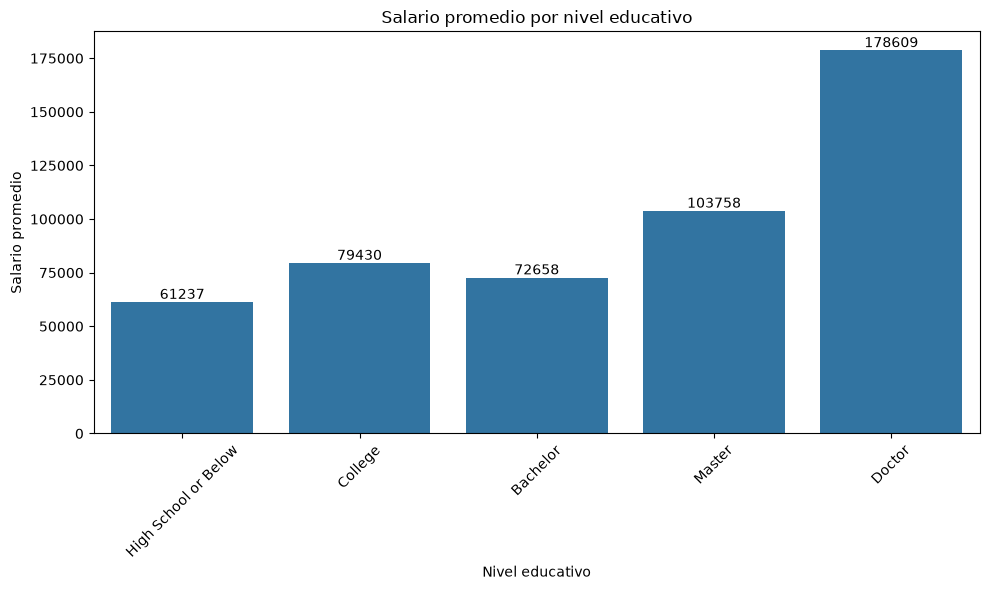

In [53]:
# Orden lógico de los niveles educativos
orden_educacion = [
    "High School or Below",
    "College",
    "Bachelor",
    "Master",
    "Doctor"
]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=salario_educacion,
    x="education",
    y="salario_promedio",
    order=orden_educacion
)

plt.title("Salario promedio por nivel educativo")
plt.xlabel("Nivel educativo")
plt.ylabel("Salario promedio")
plt.xticks(rotation=45)

for i, valor in enumerate(salario_educacion.set_index("education").loc[orden_educacion, "salario_promedio"]):
    plt.text(
        i,
        valor,
        f"{valor:.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

El salario promedio por nivel educativo sigue casi el orden de formación, a excepción de Bachelor, grupo cuyo salario promedio es menor que el de College, un nivel de estudios inferior.

In [54]:
# Cuál es la proporción de clientes con diferentes tipos de tarjetas de fidelidad?

#Agrupo los clientes por tipo de tarjeta
clientes_tarjeta = (
    df_loyalty_number.groupby("loyalty_card")["loyalty_number"].count().reset_index()
)

#Renombro la columna
clientes_tarjeta = clientes_tarjeta.rename(columns={
    "loyalty_number": "numero_clientes_tarjeta"
})

#Ordeno
clientes_tarjeta = clientes_tarjeta.sort_values(
    by="numero_clientes_tarjeta",
    ascending=False
)


clientes_tarjeta["porcentaje"] = (
    clientes_tarjeta["numero_clientes_tarjeta"] / clientes_tarjeta["numero_clientes_tarjeta"].sum() * 100
).round(2)

clientes_tarjeta

,loyalty_card,numero_clientes_tarjeta,porcentaje
2,Star,184224,45.42
1,Nova,137568,33.92
0,Aurora,83832,20.67


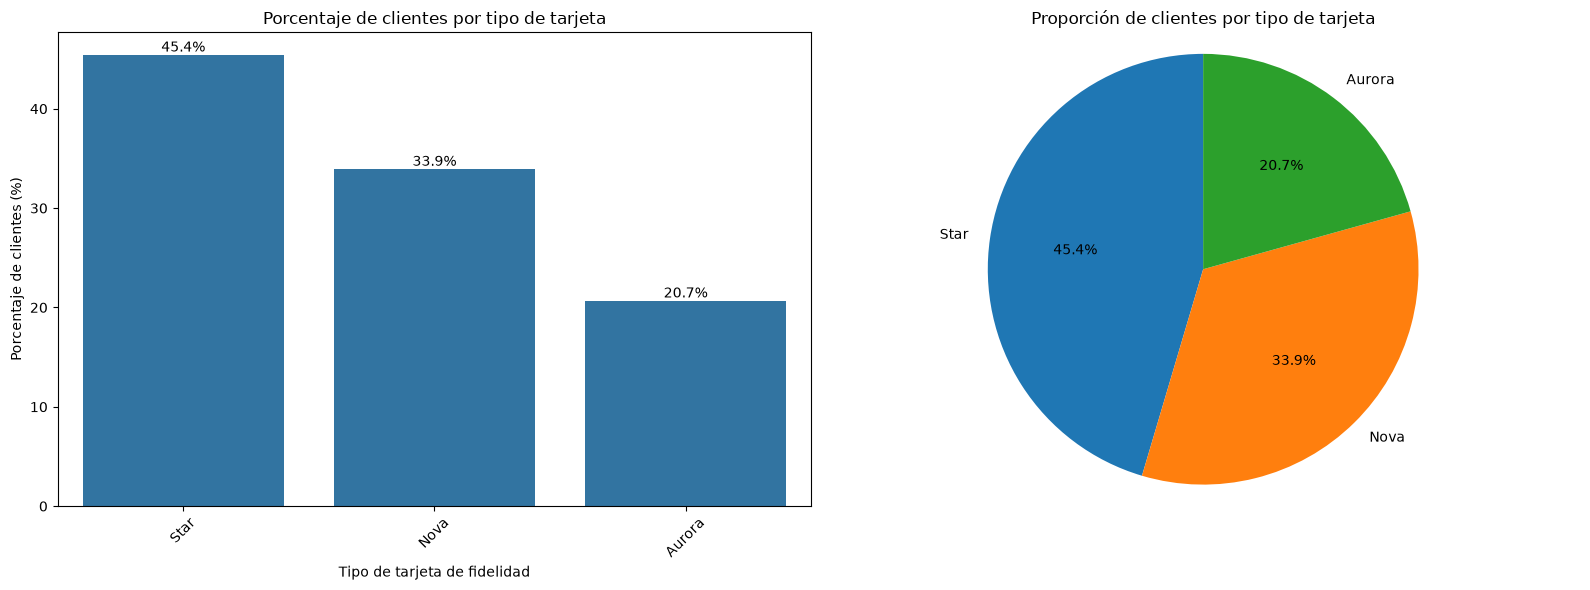

In [55]:
# Figura de 1 fila y 2 columnas
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# -----------------------------
# Gráfico de barras
# -----------------------------

sns.barplot(
    data=clientes_tarjeta,
    x="loyalty_card",
    y="porcentaje",
    ax=axes[0]
)

axes[0].set_title("Porcentaje de clientes por tipo de tarjeta")
axes[0].set_xlabel("Tipo de tarjeta de fidelidad")
axes[0].set_ylabel("Porcentaje de clientes (%)")
axes[0].tick_params(axis="x", rotation=45)

# Etiquetas encima de las barras
for i, valor in enumerate(clientes_tarjeta["porcentaje"]):
    axes[0].text(
        i,
        valor,
        f"{valor:.1f}%",
        ha="center",
        va="bottom"
    )

# -----------------------------
# Gráfico de tarta
# -----------------------------

axes[1].pie(
    clientes_tarjeta["porcentaje"],
    labels=clientes_tarjeta["loyalty_card"],
    autopct="%1.1f%%",
    startangle=90
)

axes[1].set_title("Proporción de clientes por tipo de tarjeta")
axes[1].axis("equal")  # Para que la tarta salga circular

plt.tight_layout()
plt.show()

Lo que se observa en los gráficos es que la tarjeta Star es la que tiene un mayor número de clientes, representando el 45,4% del total, seguida de la Nova, que tienen el 33,9% de los clientes. La tarjeta Aurora es la minoritaria, que poseen el 20,7% de los clientes.

In [56]:
#Cómo se distribuyen los clientes según su estado civil y género?

#Agrupo los clientes por género
clientes_genero = (
    df_loyalty_number.groupby("gender")["loyalty_number"].count().reset_index()
)

#Renombro la columna
clientes_genero = clientes_genero.rename(columns={
    "loyalty_number": "numero_clientes"
})

#Ordeno
clientes_genero = clientes_genero.sort_values(
    by="numero_clientes",
    ascending=False
)


clientes_genero["porcentaje"] = (
    clientes_genero["numero_clientes"] / clientes_genero["numero_clientes"].sum() * 100
).round(2)

clientes_genero

,gender,numero_clientes,porcentaje
0,Female,203640,50.2
1,Male,201984,49.8


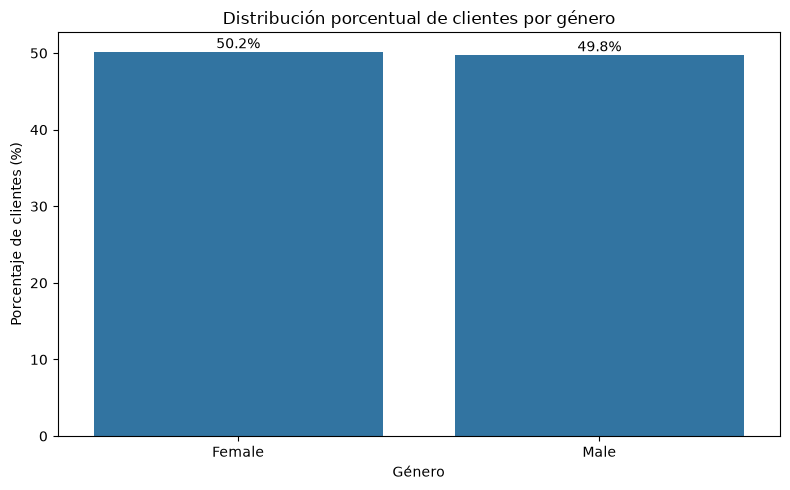

In [57]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=clientes_genero,
    x="gender",
    y="porcentaje"
)

plt.title("Distribución porcentual de clientes por género")
plt.xlabel("Género")
plt.ylabel("Porcentaje de clientes (%)")

for i, valor in enumerate(clientes_genero["porcentaje"]):
    plt.text(
        i,
        valor,
        f"{valor:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [58]:
#Agrupo los clientes por estado civil
clientes_ecivil = (
    df_loyalty_number.groupby("marital_status")["loyalty_number"].count().reset_index()
)

#Renombro la columna
clientes_ecivil = clientes_ecivil.rename(columns={
    "loyalty_number": "numero_clientes"
})

#Ordeno
clientes_ecivil = clientes_ecivil.sort_values(
    by="numero_clientes",
    ascending=False
)


clientes_ecivil["porcentaje"] = (
    clientes_ecivil["numero_clientes"] / clientes_ecivil["numero_clientes"].sum() * 100
).round(2)

clientes_ecivil

,marital_status,numero_clientes,porcentaje
1,Married,235800,58.13
2,Single,108648,26.79
0,Divorced,61176,15.08


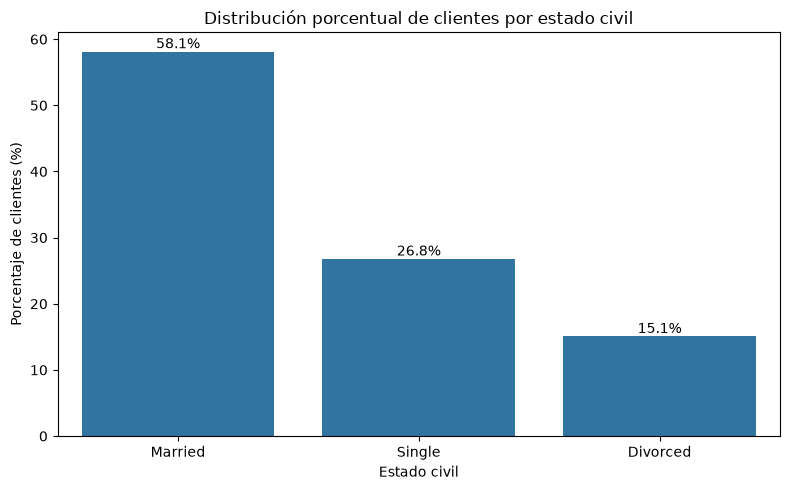

In [59]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=clientes_ecivil,
    x="marital_status",
    y="porcentaje"
)

plt.title("Distribución porcentual de clientes por estado civil")
plt.xlabel("Estado civil")
plt.ylabel("Porcentaje de clientes (%)")

for i, valor in enumerate(clientes_ecivil["porcentaje"]):
    plt.text(
        i,
        valor,
        f"{valor:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [60]:
# Distribución de género y estado civil

#Agrupo los clientes por estado civil y género
clientes_ecivil_genero = (
    df_loyalty_number.groupby(["gender","marital_status"])["loyalty_number"].count().reset_index()
)

#Renombro la columna
clientes_ecivil_genero = clientes_ecivil_genero.rename(columns={
    "loyalty_number": "numero_clientes"
})

#Ordeno
clientes_ecivil_genero = clientes_ecivil_genero.sort_values(
    by="numero_clientes",
    ascending=False
)


clientes_ecivil_genero["porcentaje"] = (
    clientes_ecivil_genero["numero_clientes"] / clientes_ecivil_genero.groupby('gender')["numero_clientes"].transform('sum') * 100
).round(2)

clientes_ecivil_genero

,gender,marital_status,numero_clientes,porcentaje
4,Male,Married,117984,58.41
1,Female,Married,117816,57.86
2,Female,Single,54936,26.98
5,Male,Single,53712,26.59
0,Female,Divorced,30888,15.17
3,Male,Divorced,30288,15.00


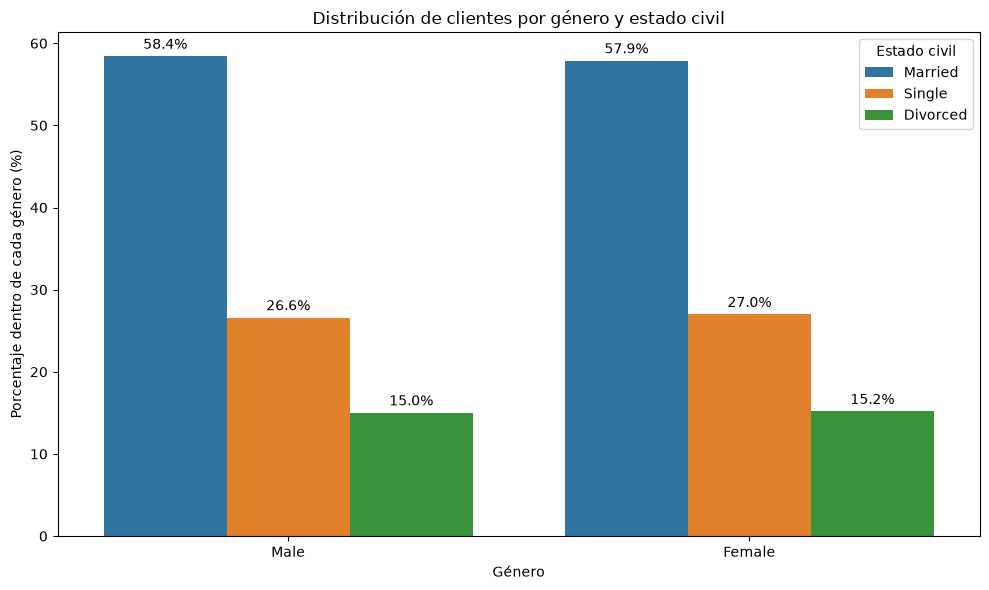

In [61]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=clientes_ecivil_genero,
    x="gender",
    y="porcentaje",
    hue="marital_status"
)

plt.title("Distribución de clientes por género y estado civil")
plt.xlabel("Género")
plt.ylabel("Porcentaje dentro de cada género (%)")
plt.legend(title="Estado civil")

for container in plt.gca().containers:
    plt.bar_label(
        container,
        fmt="%.1f%%",
        label_type="edge",
        padding=3
    )

plt.tight_layout()
plt.show()

Tal y como se observa en los gráficos individuales, hay una proporción muy similar de hombres y de mujeres. En cuanto al estado civil, la mayoría son casados (58%), seguidos de solteros y, en último lugar, divorciados.

En la distribución cojunta de estado civil por género se observa también una distribución parecida. Tanto los clientes hombres como las mujeres están mayoritariamente casados, rondando en ambos sexos el 58%. Solteros tanto mujeres como hombres están en torno al 27% y divorciados en torno al 15%.

Por lo que no hay diferencias apenas en el estado civil en función del sexo, ya que ambos presentan distribuciones muy parecidas.

## Diferencias en Reservas de Vuelos por Nivel Educativo

In [62]:
#Convierto 'loyalty_number' en columna
df_noindex = df_final.reset_index()
df_noindex = df_noindex.rename(columns={"Loyalty Number": "loyalty_number"})
df_noindex

,index,loyalty_number,year,date,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,...,marital_status,loyalty_card,clv,enrollment_type,enrollment_date,enrollment_year,cancellation_year,cancellation_date,is_cancelled,month
0,0,100018,2017,2017-01-01,3,0,3,1521,152.0,0,...,Married,Aurora,7919.20,Standard,2016-08-01,2016,NaN,NaN,False,1
1,1,100102,2017,2017-01-01,10,4,14,2030,203.0,0,...,Single,Nova,2887.74,Standard,2013-03-01,2013,NaN,NaN,False,1
2,2,100140,2017,2017-01-01,6,0,6,1200,120.0,0,...,Divorced,Nova,2838.07,Standard,2016-07-01,2016,NaN,NaN,False,1
3,3,100214,2017,2017-01-01,0,0,0,0,0.0,0,...,Married,Star,4170.57,Standard,2015-08-01,2015,NaN,NaN,False,1
4,4,100272,2017,2017-01-01,0,0,0,0,0.0,0,...,Divorced,Star,6622.05,Standard,2014-01-01,2014,NaN,NaN,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405619,405619,999902,2018,2018-12-01,0,0,0,0,0.0,0,...,Married,Aurora,7290.07,Standard,2014-05-01,2014,NaN,NaN,False,12
405620,405620,999911,2018,2018-12-01,0,0,0,0,0.0,0,...,Single,Nova,8564.77,Standard,2012-08-01,2012,NaN,NaN,False,12
405621,405621,999940,2018,2018-12-01,3,0,3,1233,123.0,0,...,Married,Nova,20266.50,Standard,2017-07-01,2017,NaN,NaN,False,12
405622,405622,999982,2018,2018-12-01,0,0,0,0,0.0,0,...,Married,Star,2631.56,Standard,2018-07-01,2018,NaN,NaN,False,12


In [63]:


#Primero sumo los vuelos de cada cliente, para hacer el análisis a nivel cliente y que los clientes no aparezcan repetidos por meses
vuelos_cliente = (df_noindex.groupby('loyalty_number')['flights_booked'].sum().reset_index())

#Renombro la columna
vuelos_cliente = vuelos_cliente.rename(columns={
    "flights_booked": "total_flights_booked"
})
vuelos_cliente

,loyalty_number,total_flights_booked
0,100018,157
1,100102,173
2,100140,152
3,100214,79
4,100272,127
...,...,...
16732,999902,178
16733,999911,0
16734,999940,63
16735,999982,22


In [64]:
#vuelvo a poner loyalty number como índice

vuelos_cliente = vuelos_cliente.set_index('loyalty_number')

vuelos_cliente

,total_flights_booked
loyalty_number,
100018,157
100102,173
100140,152
100214,79
100272,127
...,...
999902,178
999911,0
999940,63


In [65]:
#renombro columna en df_clientes

df_clientes = df_clientes.rename(columns={
    "Loyalty Number": "loyalty_number"})

In [66]:
vuelos_educacion = vuelos_cliente.merge(
    df_clientes[["loyalty_number", "education"]],
    on="loyalty_number",
    how="left"
)

vuelos_educacion.head()

,loyalty_number,total_flights_booked,education
0,100018,157,Bachelor
1,100102,173,College
2,100140,152,College
3,100214,79,Bachelor
4,100272,127,Bachelor


In [67]:
datos_educacion_vuelos = vuelos_educacion[["total_flights_booked", "education"]]

In [68]:
datos_educacion_vuelos


,total_flights_booked,education
0,157,Bachelor
1,173,College
2,152,College
3,79,Bachelor
4,127,Bachelor
...,...,...
16732,178,College
16733,0,Doctor
16734,63,Bachelor
16735,22,College


In [69]:
# Análisis por nivel educativo

estadisticas_educacion = (
    datos_educacion_vuelos.groupby("education")["total_flights_booked"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reset_index()
    .rename(columns={
        "count": "numero_clientes",
        "mean": "media_vuelos_reservados",
        "median": "mediana",
        "std": "desviacion_estandar",
        "min": "minimo",
        "max": "maximo",
    })
    .round(2)
)

estadisticas_educacion

,education,numero_clientes,media_vuelos_reservados,mediana,desviacion_estandar,minimo,maximo
0,Bachelor,10475,99.10,113.0,54.23,0,354
1,College,4238,100.61,113.0,54.21,0,324
2,Doctor,734,100.87,115.0,55.93,0,292
3,High School or Below,782,101.01,115.0,54.87,0,265
4,Master,508,101.60,113.0,54.02,0,322


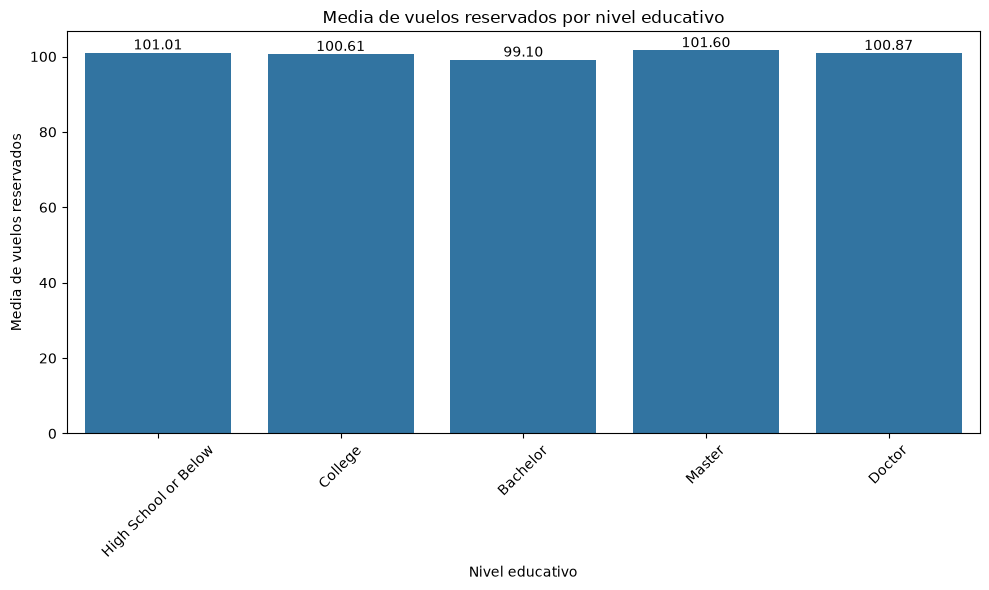

In [70]:
orden_educacion = [
    "High School or Below",
    "College",
    "Bachelor",
    "Master",
    "Doctor"
]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=estadisticas_educacion,
    x="education",
    y="media_vuelos_reservados",
    order=orden_educacion
)

plt.title("Media de vuelos reservados por nivel educativo")
plt.xlabel("Nivel educativo")
plt.ylabel("Media de vuelos reservados")
plt.xticks(rotation=45)

for i, valor in enumerate(
    estadisticas_educacion.set_index("education").loc[orden_educacion, "media_vuelos_reservados"]
):
    plt.text(
        i,
        valor,
        f"{valor:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

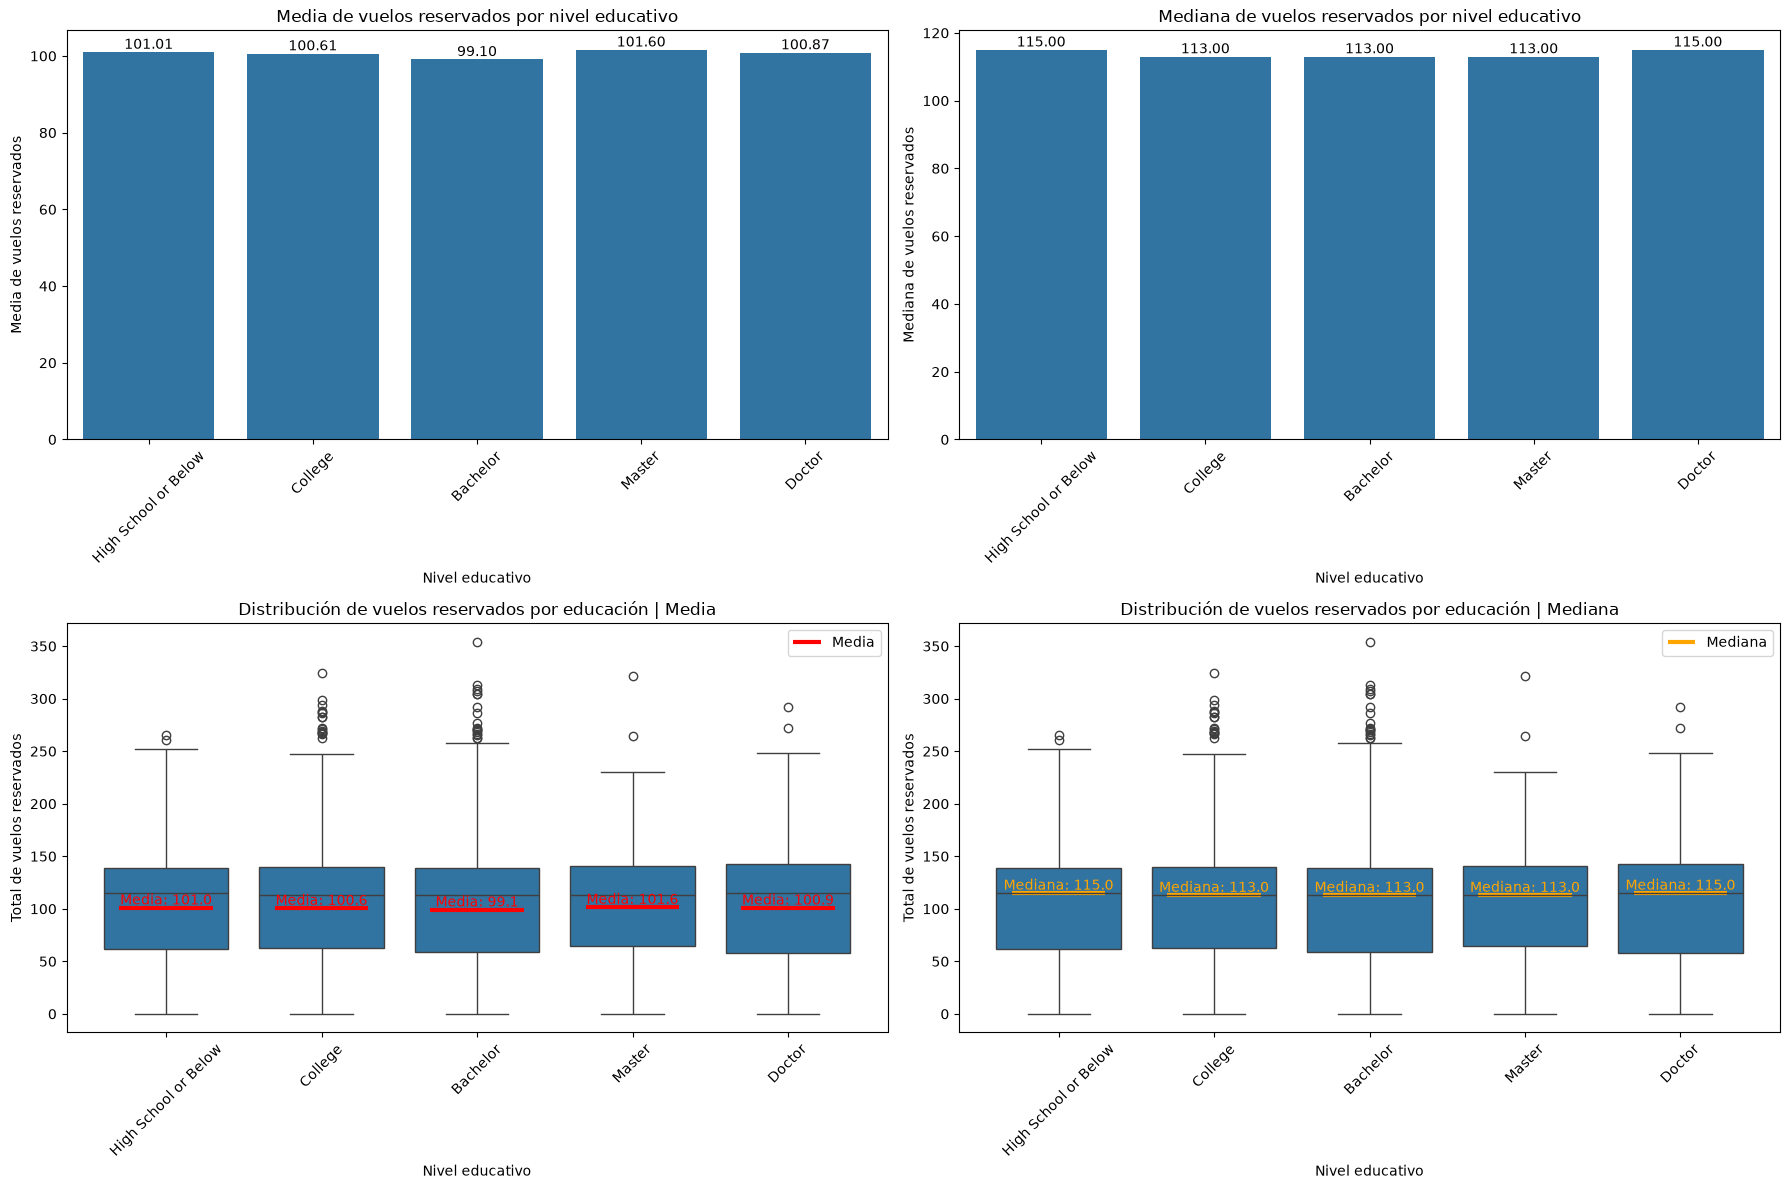

In [71]:
orden_educacion = [
    "High School or Below",
    "College",
    "Bachelor",
    "Master",
    "Doctor"
]

orden_educacion = [
    categoria for categoria in orden_educacion
    if categoria in datos_educacion_vuelos["education"].unique()
]

estadisticas_educacion["education"] = pd.Categorical(
    estadisticas_educacion["education"],
    categories=orden_educacion,
    ordered=True
)

estadisticas_educacion = estadisticas_educacion.sort_values("education")

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))

# 1. Barras: media
sns.barplot(
    data=estadisticas_educacion,
    x="education",
    y="media_vuelos_reservados",
    ax=axes[0, 0]
)

axes[0, 0].set_title("Media de vuelos reservados por nivel educativo")
axes[0, 0].set_xlabel("Nivel educativo")
axes[0, 0].set_ylabel("Media de vuelos reservados")
axes[0, 0].tick_params(axis="x", rotation=45)

for i, valor in enumerate(estadisticas_educacion["media_vuelos_reservados"]):
    axes[0, 0].text(i, valor, f"{valor:.2f}", ha="center", va="bottom")


# 2. Barras: mediana
sns.barplot(
    data=estadisticas_educacion,
    x="education",
    y="mediana",
    ax=axes[0, 1]
)

axes[0, 1].set_title("Mediana de vuelos reservados por nivel educativo")
axes[0, 1].set_xlabel("Nivel educativo")
axes[0, 1].set_ylabel("Mediana de vuelos reservados")
axes[0, 1].tick_params(axis="x", rotation=45)

for i, valor in enumerate(estadisticas_educacion["mediana"]):
    axes[0, 1].text(i, valor, f"{valor:.2f}", ha="center", va="bottom")


# 3. Boxplot con media señalada
sns.boxplot(
    data=datos_educacion_vuelos,
    x="education",
    y="total_flights_booked",
    order=orden_educacion,
    ax=axes[1, 0]
)

axes[1, 0].set_title("Distribución de vuelos reservados por educación | Media")
axes[1, 0].set_xlabel("Nivel educativo")
axes[1, 0].set_ylabel("Total de vuelos reservados")
axes[1, 0].tick_params(axis="x", rotation=45)

for i, categoria in enumerate(orden_educacion):
    media = estadisticas_educacion.loc[
        estadisticas_educacion["education"] == categoria,
        "media_vuelos_reservados"
    ].values[0]

    # Línea roja de la media sobre cada boxplot
    axes[1, 0].hlines(
        y=media,
        xmin=i - 0.30,
        xmax=i + 0.30,
        colors="red",
        linewidth=3,
        label="Media" if i == 0 else ""
    )

    axes[1, 0].text(
        i,
        media,
        f"Media: {media:.1f}",
        ha="center",
        va="bottom",
        color="red"
    )

axes[1, 0].legend()


# 4. Boxplot con mediana señalada en naranja
sns.boxplot(
    data=datos_educacion_vuelos,
    x="education",
    y="total_flights_booked",
    order=orden_educacion,
    ax=axes[1, 1]
)

axes[1, 1].set_title("Distribución de vuelos reservados por educación | Mediana")
axes[1, 1].set_xlabel("Nivel educativo")
axes[1, 1].set_ylabel("Total de vuelos reservados")
axes[1, 1].tick_params(axis="x", rotation=45)

for i, categoria in enumerate(orden_educacion):
    mediana = estadisticas_educacion.loc[
        estadisticas_educacion["education"] == categoria,
        "mediana"
    ].values[0]

    # Línea naranja de la mediana sobre cada boxplot
    axes[1, 1].hlines(
        y=mediana,
        xmin=i - 0.30,
        xmax=i + 0.30,
        colors="orange",
        linewidth=3,
        label="Mediana" if i == 0 else ""
    )

    axes[1, 1].text(
        i,
        mediana,
        f"Mediana: {mediana:.1f}",
        ha="center",
        va="bottom",
        color="orange"
    )

axes[1, 1].legend()

plt.tight_layout()
plt.show()

Al analizar el total de vuelos reservados por cliente según el nivel educativo, no se observan diferencias relevantes entre los grupos. Las medias se sitúan en valores muy similares, alrededor de los 100 vuelos reservados, mientras que las medianas oscilan entre 113 y 115 vuelos. Además, los boxplots muestran distribuciones muy parecidas entre los distintos niveles educativos, tanto en la posición central como en la dispersión. Por tanto, a nivel descriptivo, el nivel educativo no parece estar asociado a diferencias importantes en la cantidad de vuelos reservados.

En todos los grupos, la mediana es superior a la media, lo que sugiere que existen clientes con valores bajos de vuelos reservados que reducen el promedio. Por este motivo, la mediana puede ser una medida más representativa del comportamiento típico de los clientes.

In [78]:
# Análisis extra: relación entre el salario y los viajes


vuelos_por_cliente = (
    df_final
    .groupby("loyalty_number")["flights_booked"]
    .sum()
    .reset_index()
    .rename(columns={"flights_booked": "total_flights_booked"})
)


salario_vuelos = vuelos_por_cliente.merge(
    df_clientes[["loyalty_number", "salary"]],
    on="loyalty_number",
    how="left"
)

salario_vuelos.head()

,loyalty_number,total_flights_booked,salary
0,100018,157,92552.000000
1,100102,173,79429.572642
2,100140,152,79429.572642
3,100214,79,63253.000000
4,100272,127,91163.000000


In [79]:
df_corr_salario_vuelos = salario_vuelos[["salary", "total_flights_booked"]].dropna()

correlacion = df_corr_salario_vuelos["salary"].corr(
    df_corr_salario_vuelos["total_flights_booked"]
)

print(f"Correlación entre salario y total de vuelos reservados: {correlacion:.2f}")

Correlación entre salario y total de vuelos reservados: 0.01


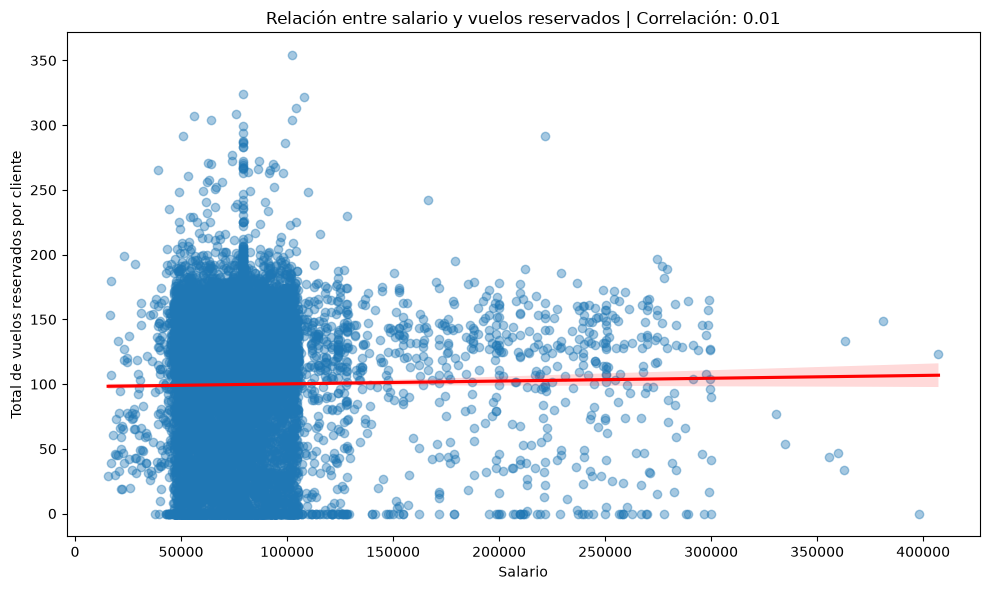

In [80]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_corr_salario_vuelos,
    x="salary",
    y="total_flights_booked",
    scatter_kws={"alpha": 0.4},
    line_kws={"color": "red"}
)

plt.title(f"Relación entre salario y vuelos reservados | Correlación: {correlacion:.2f}")
plt.xlabel("Salario")
plt.ylabel("Total de vuelos reservados por cliente")

plt.tight_layout()
plt.show()

El salario tampoco parece tener relación con la reserva de un mayor número de vuelos